In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [39]:
# Dataset name
file_name = "PS_2026.04.01_18.53.37.csv"
# Read the file
df = pd.read_csv(file_name, comment="#")
# Preview cleaned dataset
df.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,rastr,ra,decstr,dec,sy_dist,sy_disterr1,sy_disterr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,1,2,1,323.21000,0.06,-0.05,0.0,1.178,...,12h20m42.91s,185.178779,+17d47m35.71s,17.793252,93.1846,1.9238,-1.9238,4.44038,0.003848,-0.003848
1,11 Com b,11 Com,0,2,1,326.03000,0.32,-0.32,0.0,1.290,...,12h20m42.91s,185.178779,+17d47m35.71s,17.793252,93.1846,1.9238,-1.9238,4.44038,0.003848,-0.003848
2,11 Com b,11 Com,0,2,1,NaN,NaN,NaN,NaN,1.210,...,12h20m42.91s,185.178779,+17d47m35.71s,17.793252,93.1846,1.9238,-1.9238,4.44038,0.003848,-0.003848
3,11 UMi b,11 UMi,0,1,1,NaN,NaN,NaN,NaN,1.510,...,15h17m05.90s,229.274595,+71d49m26.19s,71.823943,125.3210,1.9765,-1.9765,4.56216,0.003903,-0.003903
4,11 UMi b,11 UMi,1,1,1,516.21997,3.20,-3.20,0.0,1.530,...,15h17m05.90s,229.274595,+71d49m26.19s,71.823943,125.3210,1.9765,-1.9765,4.56216,0.003903,-0.003903


In [40]:
# Initial feature set used
features = ["pl_rade", "pl_bmasse", "pl_eqt", "pl_orbsmax"]
# Print total number of planets in the raw dataset
print("Total rows:", len(df))
# Count missing values for each selected feature
print("\nMissing values per feature:")
print(df[features].isna().sum())

Total rows: 39537

Missing values per feature:
pl_rade       12329
pl_bmasse     32197
pl_eqt        22185
pl_orbsmax    17347
dtype: int64


In [41]:
# Simplified initial model:
# Remove planetary mass because it has too many missing values
# Keep radius, equilibrium temperature, and orbital distance
features = ["pl_rade", "pl_eqt", "pl_orbsmax"]
# Keep only rows with complete data for these three variables
data_env = df[["pl_name"] +features].dropna()

print(len(data_env))
# Summary statistics of the cleaned initial dataset
data_env.describe()

15449


,pl_rade,pl_eqt,pl_orbsmax
count,15449.000000,15449.000000,15449.000000
mean,5.955872,864.098433,1.015546
std,87.888272,412.450582,64.267587
min,0.270000,124.700000,0.005000
25%,1.510000,564.000000,0.051200
50%,2.210000,787.000000,0.087600
75%,3.100000,1073.000000,0.156100
max,4282.980000,4050.000000,7506.000000


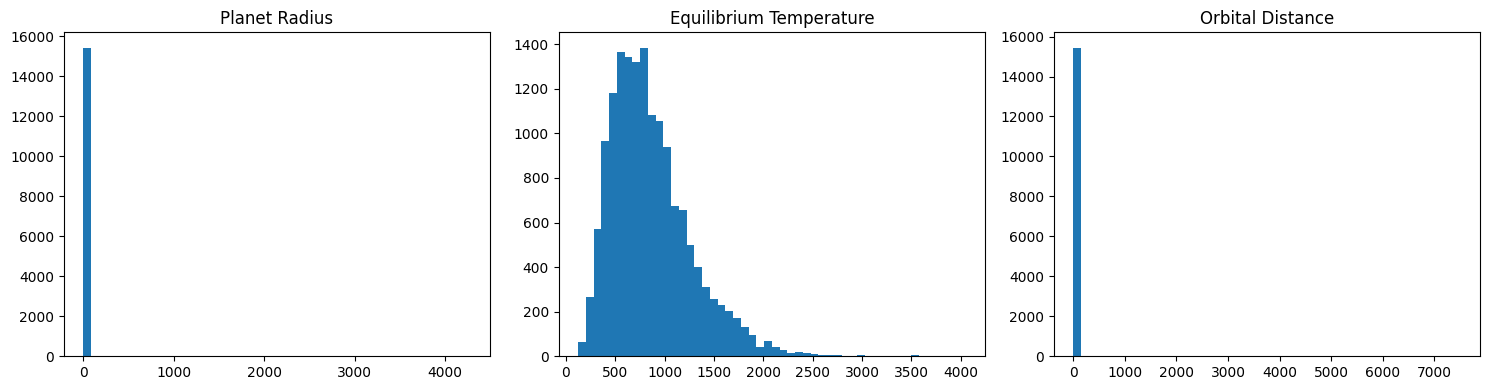

In [42]:
# Visualize the distributions of the three original features. This helps identify skewness, outliers, and scaling differences
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data_env["pl_rade"], bins=50)
axes[0].set_title("Planet Radius")

axes[1].hist(data_env["pl_eqt"], bins=50)
axes[1].set_title("Equilibrium Temperature")

axes[2].hist(data_env["pl_orbsmax"], bins=50)
axes[2].set_title("Orbital Distance")

plt.tight_layout()
plt.show()

In [43]:
# Apply log10 transformation to reduce heavy right-skewed distributions. This makes variables more balanced for clustering algorithms
data_env["log_rade"] = np.log10(data_env["pl_rade"])
data_env["log_eqt"] = np.log10(data_env["pl_eqt"])
data_env["log_orbsmax"] = np.log10(data_env["pl_orbsmax"])

data_env[["log_rade", "log_eqt", "log_orbsmax"]].describe()

,log_rade,log_eqt,log_orbsmax
count,15449.000000,15449.000000,15449.000000
mean,0.392630,2.889211,-1.035665
std,0.334426,0.205816,0.385245
min,-0.568636,2.095866,-2.301030
25%,0.178977,2.751279,-1.290730
50%,0.344392,2.895975,-1.057496
75%,0.491362,3.030600,-0.806597
max,3.631746,3.607455,3.875409


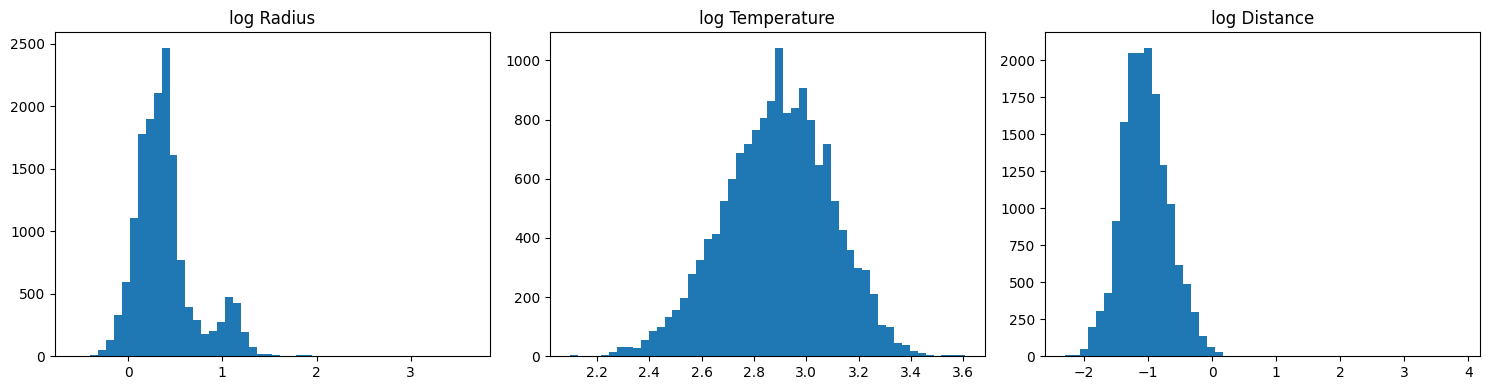

In [44]:
# Plot histograms after log transformation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data_env["log_rade"], bins=50)
axes[0].set_title("log Radius")

axes[1].hist(data_env["log_eqt"], bins=50)
axes[1].set_title("log Temperature")

axes[2].hist(data_env["log_orbsmax"], bins=50)
axes[2].set_title("log Distance")

plt.tight_layout()
plt.show()

In [45]:
# Select transformed features for clustering
X = data_env[["log_rade", "log_eqt", "log_orbsmax"]]
# Standardize features to mean = 0 and std = 1
# Prevents variables with larger ranges from dominating KMeans distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)

Shape: (15449, 3)


In [46]:
# Test multiple values of k to determine an appropriate number of clusters
k_values = range(2, 7)
scores = []

for k in k_values:
    # Train KMeans with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    # Compute silhouette score
    score = silhouette_score(X_scaled, labels)
    
    print(f"k={k}, silhouette={score:.4f}")
    scores.append(score)

k=2, silhouette=0.3365
k=3, silhouette=0.3890
k=4, silhouette=0.3328
k=5, silhouette=0.2853
k=6, silhouette=0.2815


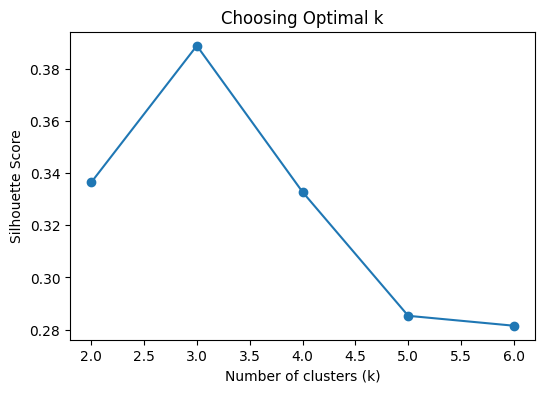

In [47]:
# Plot silhouette score vs number of clusters
plt.figure(figsize=(6,4))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Choosing Optimal k")
plt.show()

In [48]:
# Train final KMeans model using selected k = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
# Save cluster labels into the dataframe
data_env["cluster"] = labels
# Show number of planets in each cluster
print(data_env["cluster"].value_counts())

cluster
0    7688
1    6140
2    1621
Name: count, dtype: int64


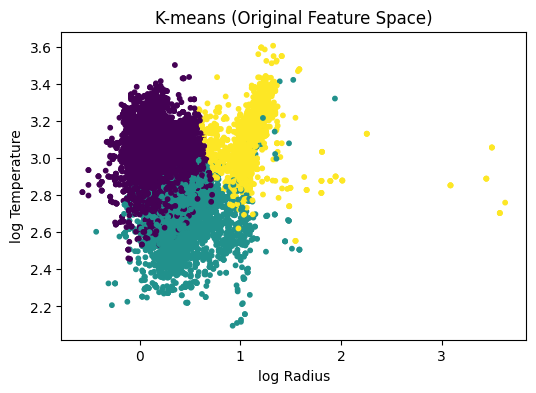

In [49]:
# Visualize clustering result in original feature space
# x-axis = log radius, y-axis = log temperature
plt.figure(figsize=(6,4))
plt.scatter(data_env["log_rade"], data_env["log_eqt"],
            c=data_env["cluster"], s=10)
plt.xlabel("log Radius")
plt.ylabel("log Temperature")
plt.title("K-means (Original Feature Space)")
plt.show()

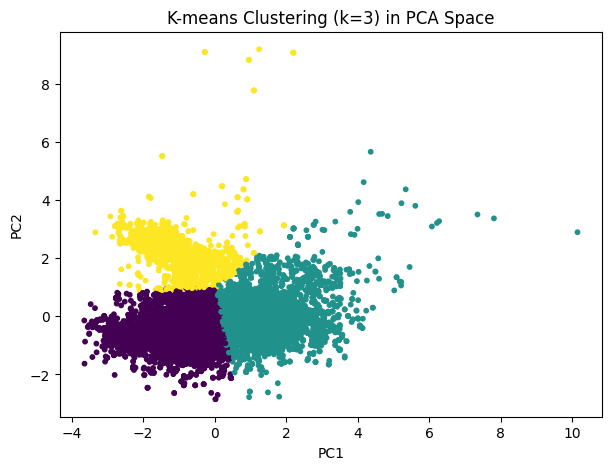

In [50]:
# Reduce the 3-dimensional standardized feature space to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Store PCA coordinates in the dataframe
data_env["PC1"] = X_pca[:, 0]
data_env["PC2"] = X_pca[:, 1]
# Plot KMeans clusters in PCA space
plt.figure(figsize=(7,5))
plt.scatter(data_env["PC1"], data_env["PC2"], c=data_env["cluster"], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clustering (k=3) in PCA Space")

plt.show()

In [51]:
# Compute mean physical properties for each KMeans cluster
print(data_env.groupby("cluster")[[
    "pl_rade", "pl_eqt", "pl_orbsmax"
]].mean())

           pl_rade       pl_eqt  pl_orbsmax
cluster                                    
0         1.811662  1025.865532    0.063087
1         3.111121   533.030375    2.460281
2        36.386134  1350.892030    0.060476


In [52]:
# Test DBSCAN as a comparison clustering method
# DBSCAN groups points based on density and can label outliers as noise
dbscan = DBSCAN(eps=0.7, min_samples=100)
db_labels = dbscan.fit_predict(X_scaled)

data_env["dbscan_cluster"] = db_labels
# Display number of planets in each DBSCAN group
print(data_env["dbscan_cluster"].value_counts().sort_index())

dbscan_cluster
-1      230
 0    15219
Name: count, dtype: int64


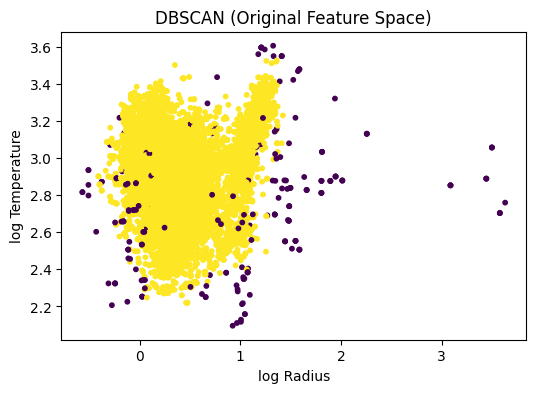

In [53]:
# Visualize DBSCAN results in the original feature space
# x-axis = log radius, y-axis = log temperature
plt.figure(figsize=(6,4))
plt.scatter(data_env["log_rade"], data_env["log_eqt"],
            c=data_env["dbscan_cluster"], s=10)
plt.xlabel("log Radius")
plt.ylabel("log Temperature")
plt.title("DBSCAN (Original Feature Space)")
plt.show()

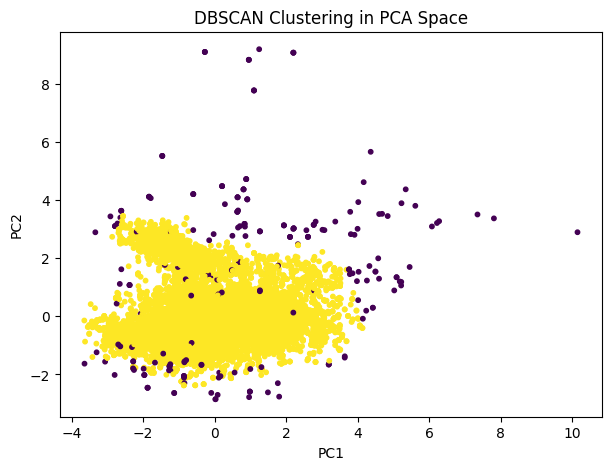

In [54]:
# Visualize DBSCAN clusters in PCA-reduced space
plt.figure(figsize=(7,5))
plt.scatter(data_env["PC1"], data_env["PC2"], c=data_env["dbscan_cluster"], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering in PCA Space")
plt.show()

In [55]:
# Create a subset containing planets with both radius and mass measurements
data_mass = df[["pl_rade", "pl_bmasse"]].dropna()
# Compute a simple density proxy:
data_mass["density"] = data_mass["pl_bmasse"] / (data_mass["pl_rade"]**3)

In [56]:
# Join density values with the previously assigned KMeans clusters
# Then compute average density for each cluster
print(data_env.join(data_mass["density"]).groupby("cluster")["density"].mean())

cluster
0    3.888949
1    1.323763
2    0.270113
Name: density, dtype: float64


In [59]:
# Followed code was assisted by Chatgpt
# Create density validation subset using planets with measured mass
data_mass = df[["pl_name","pl_rade","pl_bmasse"]].dropna().copy()

# Density proxy
data_mass["density"] = data_mass["pl_bmasse"] / (data_mass["pl_rade"]**3)

print("Planets with mass data:", len(data_mass))

# Remove duplicate planet names so each planet appears once
data_mass = data_mass.drop_duplicates(subset="pl_name")
data_env2 = data_env.drop_duplicates(subset="pl_name")

# Merge with clustering results
data_merged = data_env2.merge(
    # Keep only planet name and density column from the mass subset
    data_mass[["pl_name","density"]],
    # Use planet name as the matching key in both tables
    on="pl_name",
    # Inner join keeps only planets found in BOTH datasets
    how="inner"
)

print("Rows after merge:", len(data_merged))

Planets with mass data: 3339
Rows after merge: 1532


In [60]:
# Compare density distributions across clusters

# Mean density by cluster
print(data_merged.groupby("cluster")["density"].mean())
# Median density by cluster. Median is useful because density can contain extreme outliers
print("\nMedian:")
print(data_merged.groupby("cluster")["density"].median())

cluster
0    6.253937
1    1.647778
2    0.738468
Name: density, dtype: float64

Median:
cluster
0    0.882292
1    0.524741
2    0.121832
Name: density, dtype: float64
